## Components of Feature Engineering

Feature engineering is a crucial step in the machine learning pipeline that involves creating new features or transforming existing ones to improve the performance of a model. The components of feature engineering include:

1. **Feature Creation**: This involves generating new features from the existing data. For example, if you have a dataset with a date column, you can create new features such as the day of the week, month, or year.
2. **Feature Transformation**: This involves modifying the scale or distribution of existing features. For example, you can apply logarithmic transformations to reduce skewness or normalize features to a standard scale.
3. **Feature Selection**: This involves choosing the most relevant features for the model. Techniques such as correlation analysis, recursive feature elimination, or feature importance from tree-based models can be used to select the best features.
4. **Feature Encoding**: This involves converting categorical variables into a format that can be used by machine learning algorithms. Techniques such as one-hot encoding, label encoding, or target encoding can be used for this purpose.

## Feature Scaling

Feature scaling is a technique used to standardize the range of independent variables or features of data.

### Standardization (Z-score normalization)
Standardization transforms the data to have a mean of 0 and a standard deviation of 1


In [1]:
import numpy as np
import pandas as pd

In [17]:
# Z-score normalization
np.random.seed(88)

n_students = 100

age = np.random.randint(20,60, n_students)

cgpa = np.random.normal(8, 3 , n_students)
cgpa = np.round(cgpa, 2)
cgpa = np.clip(cgpa, 4.0, 10.0)

placement_prob = (cgpa - 4.0) / 6.0  # Maps 4.0->0.0, 10.0->1.0
placement = (np.random.random(n_students) < placement_prob).astype(int)

df = pd.DataFrame({
    'age': age,
    'cgpa': cgpa,
    'placement': placement})

df['age_scaled'] = (df['age'] - df['age'].mean()) / df['age'].std()
df['cgpa_scaled'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

pd.reset_option('display.max_rows')
df

,age,cgpa,placement,age_scaled,cgpa_scaled
0,44,9.04,1,0.433300,0.752539
1,52,5.19,0,1.139288,-1.162002
2,35,4.00,0,-0.360936,-1.753770
3,40,8.94,1,0.080306,0.702811
4,57,4.15,0,1.580531,-1.679177
...,...,...,...,...,...
95,29,6.14,0,-0.890428,-0.689583
96,57,6.95,1,1.580531,-0.286783
97,20,4.00,0,-1.684664,-1.753770
98,56,7.41,0,1.492282,-0.058033


In [18]:
X_train = df[['age', 'cgpa']]

X_train_scaled = pd.DataFrame({'age_scaled': df['age_scaled'], 'cgpa_scaled': df['cgpa_scaled']})
np.round(X_train_scaled.describe(), 1)

,age_scaled,cgpa_scaled
count,100.0,100.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.7,-1.8
25%,-0.9,-0.8
50%,-0.0,0.1
75%,0.8,1.0
max,1.8,1.2


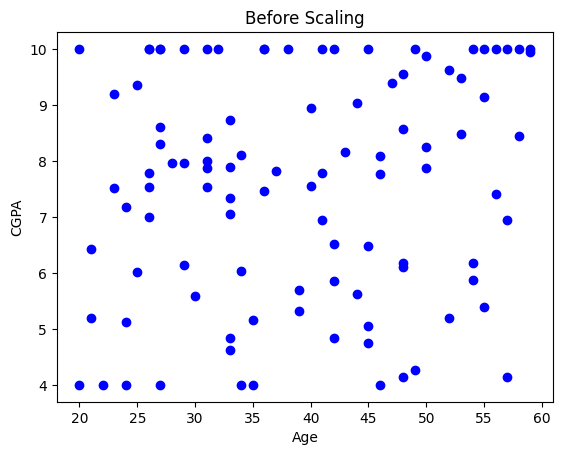

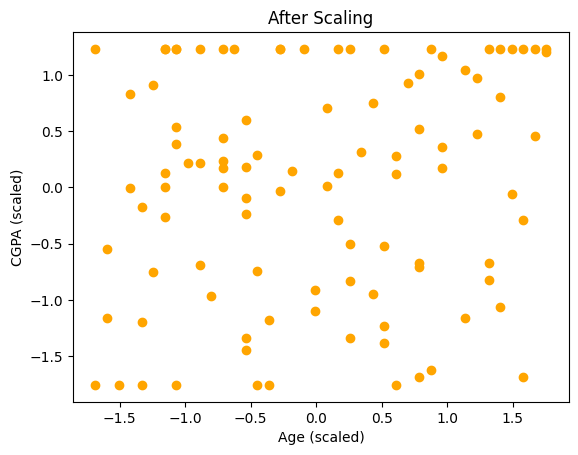

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.scatter(x=df['age'], y=df['cgpa'],color='blue')
plt.title('Before Scaling')
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.show()

plt.scatter(x=df['age_scaled'], y=df['cgpa_scaled'] ,color='orange')
plt.title('After Scaling')
plt.xlabel('Age (scaled)')
plt.ylabel('CGPA (scaled)')
plt.show()

C:\Users\biswa\AppData\Local\Temp\ipykernel_4716\4244487466.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['age'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_4716\4244487466.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['cgpa'], color='orange', shade=True)


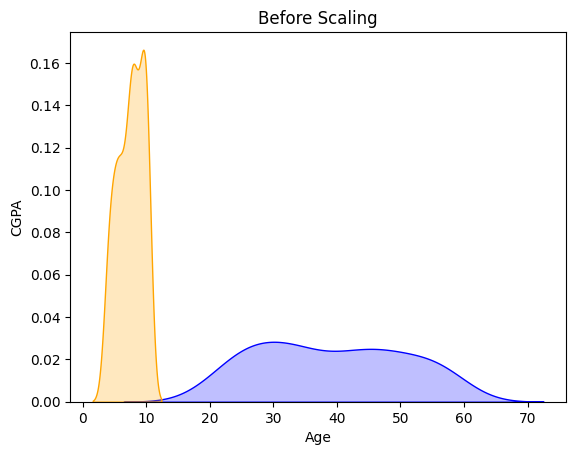

C:\Users\biswa\AppData\Local\Temp\ipykernel_4716\4244487466.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['age_scaled'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_4716\4244487466.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['cgpa_scaled'], color='orange', shade=True)


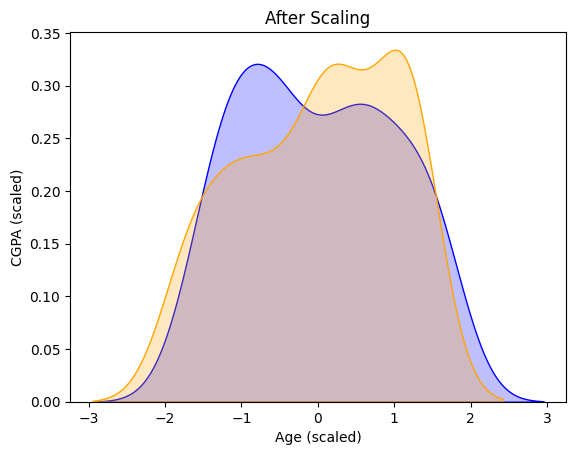

In [25]:
sns.kdeplot(x=X_train['age'], color='blue', shade=True)
sns.kdeplot(x=X_train['cgpa'], color='orange', shade=True)
plt.title('Before Scaling')
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.show()

sns.kdeplot(x=X_train_scaled['age_scaled'], color='blue', shade=True)
sns.kdeplot(x=X_train_scaled['cgpa_scaled'], color='orange', shade=True)
plt.title('After Scaling')
plt.xlabel('Age (scaled)')
plt.ylabel('CGPA (scaled)')
plt.show()

### Algorithms that are sensitive to Standardization:

- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)
- Kmeans Clustering
- Principal Component Analysis (PCA)
- Logistic Regression
- Artificial Neural Networks (ANN)
- Gradient Descent based algorithms

### Normalization (Min-Max Scaling)
Normalization scales the data to a fixed range, usually 0 to 1.

#### Min-Max Scaling 

In [51]:
import sklearn.datasets as datasets
from sklearn.preprocessing import StandardScaler, MinMaxScaler

wine = datasets.load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [56]:
wine = wine_df[['alcohol', 'malic_acid', 'ash', 'magnesium','target']]
wine

,alcohol,malic_acid,ash,magnesium,target
0,14.23,1.71,2.43,127.0,0
1,13.20,1.78,2.14,100.0,0
2,13.16,2.36,2.67,101.0,0
3,14.37,1.95,2.50,113.0,0
4,13.24,2.59,2.87,118.0,0
...,...,...,...,...,...
173,13.71,5.65,2.45,95.0,2
174,13.40,3.91,2.48,102.0,2
175,13.27,4.28,2.26,120.0,2
176,13.17,2.59,2.37,120.0,2


In [58]:
from sklearn.model_selection import train_test_split

X = wine[['alcohol', 'malic_acid', 'ash', 'magnesium']]
y = wine['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=88)

In [70]:
# Min-Max Scaling
scalar = MinMaxScaler()

scalar.fit(X_train)

X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [71]:
np.round(X_train_scaled.describe(), decimals=1)

,alcohol,malic_acid,ash,magnesium
count,142.0,142.0,142.0,142.0
mean,0.5,0.3,0.5,0.3
std,0.2,0.2,0.2,0.2
min,0.0,0.0,0.0,0.0
25%,0.4,0.1,0.5,0.2
50%,0.5,0.2,0.5,0.3
75%,0.7,0.5,0.6,0.4
max,1.0,1.0,1.0,1.0


C:\Users\biswa\AppData\Local\Temp\ipykernel_4716\793378467.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['alcohol'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_4716\793378467.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['malic_acid'], color='orange', shade=True)


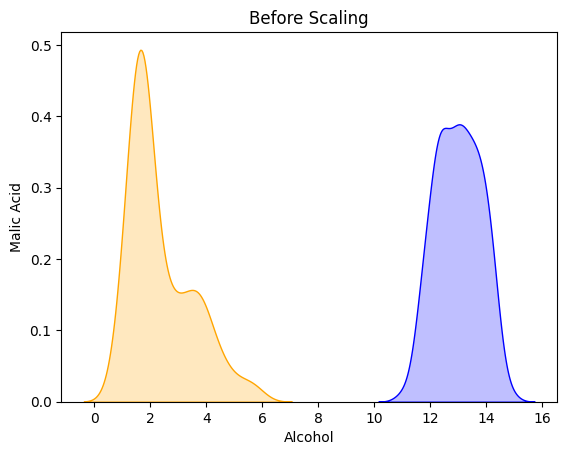

C:\Users\biswa\AppData\Local\Temp\ipykernel_4716\793378467.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['alcohol'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_4716\793378467.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['malic_acid'], color='orange', shade=True)


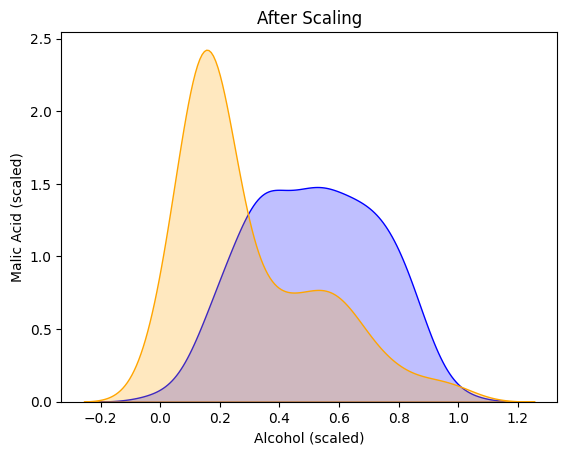

In [72]:
sns.kdeplot(x=X_train['alcohol'], color='blue', shade=True)
sns.kdeplot(x=X_train['malic_acid'], color='orange', shade=True)
plt.title('Before Scaling')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

sns.kdeplot(x=X_train_scaled['alcohol'], color='blue', shade=True)
sns.kdeplot(x=X_train_scaled['malic_acid'], color='orange', shade=True)
plt.title('After Scaling')  
plt.xlabel('Alcohol (scaled)')
plt.ylabel('Malic Acid (scaled)')
plt.show()

#### Mean Normalization

**X_mean_norm = (X - X.mean()) / (X.max() - X.min())**

#### Max Abs Scaling
**X_max_abs_scaled = X / X.abs().max()**

#### Robust Scaling
Robust Scaling uses the median and the interquartile range for scaling, making it robust to outliers.

**X_robust_scaled = (X - X.median()) / (X.quantile(0.75) - X.quantile(0.25))**

It is Robust to outliers because it uses the median and interquartile range instead of mean and standard deviation, which can be heavily influenced by outliers.

### Encoding Categorical Data
Categorical data can be encoded using various techniques such as:

#### Ordinal Encoding

Ordinal encoding assigns a unique integer to each category in a feature. This method is suitable for ordinal data where the categories have a **meaningful order.** 
For example, if you have a feature "Education Level" with categories "High School", "Bachelor's", "Master's", and "PhD", you can encode them as 0, 1, 2, and 3 respectively.

In [76]:
import numpy as np
import pandas as pd

np.random.seed(88)

score = np.random.randint(0, 101, 100)

category = ['A' , 'B' , 'C']
categories = np.random.choice(category, 100)

df = pd.DataFrame({'score': score, 'category': categories})

grade = np.where(categories == 'A' , 1 , np.where(categories == 'B', 2, np.where(categories == 'C', 3, 0)))

df_with_ordinal = pd.DataFrame({'score': score, 'category': categories, 'grade': grade})
df_with_ordinal.head()

,score,category,grade
0,88,A,1
1,32,B,2
2,79,C,3
3,49,C,3
4,20,B,2
